<a href="https://colab.research.google.com/github/datacoder2005/Azure_based_demand_forecasting_and_capacity_optimization_InfosysSpringboard_PriyankarMitra/blob/main/Infosys_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preprocessing

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Infosys project/Dataset.csv")

df = df.drop_duplicates()

df["region"] = (
    df["region"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", " ", regex=False)
    .str.replace("_", " ", regex=False)
)

official_regions = {
    "east us": "East US", "east us 2": "East US 2", "west us": "West US", "west us 2": "West US 2", "west us 3": "West US 3",
    "central us": "Central US", "north central us": "North Central US", "south central us": "South Central US",
    "canada central": "Canada Central", "canada east": "Canada East", "brazil south": "Brazil South",
    "north europe": "North Europe", "west europe": "West Europe", "uk south": "UK South", "uk west": "UK West",
    "france central": "France Central", "germany west central": "Germany West Central", "norway east": "Norway East",
    "switzerland north": "Switzerland North", "uae north": "UAE North", "south africa north": "South Africa North",
    "india central": "India Central", "india south": "India South", "india west": "India West",
    "japan east": "Japan East", "japan west": "Japan West", "korea central": "Korea Central", "korea south": "Korea South",
    "australia east": "Australia East", "australia southeast": "Australia Southeast",
    "southeast asia": "Southeast Asia", "east asia": "East Asia"
}

df["region"] = df["region"].map(official_regions)

df = df.dropna(subset=["region"])

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["region", "service_type", "timestamp"])

df["usage_units"] = df.groupby(["region", "service_type"])[
    "usage_units"].transform(lambda x: x.interpolate())
df["availability_pct"] = df.groupby(["region", "service_type"])[
    "availability_pct"].transform(lambda x: x.interpolate())

df["cost_usd"] = df["cost_usd"].fillna(df["usage_units"] * df["unit_price"])

df["utilization_pct"] = df["usage_units"] / df["provisioned_capacity"]
df["headroom_units"] = df["provisioned_capacity"] - df["usage_units"]
df["wasted_capacity_cost"] = df["headroom_units"] * df["unit_price"]

df = df.reset_index(drop=True)

print(df.isnull().sum())
print(df.head())

timestamp                   0
region                      0
service_type                0
usage_units                 0
provisioned_capacity        0
utilization_pct             0
headroom_units              0
unit_price                  0
cost_usd                    0
wasted_capacity_cost        0
availability_pct            0
sla_violation_flag          0
incident_count              0
mttr_minutes                0
daily_growth_rate           0
weekly_seasonality_index    0
spike_flag                  0
gdp_growth_rate             0
it_spending_index           0
enterprise_demand_index     0
internet_traffic_growth     0
dtype: int64
   timestamp          region service_type  usage_units  provisioned_capacity  \
0 2022-01-01  Australia East      Compute      4185.61               8660.71   
1 2022-01-02  Australia East      Compute      3992.20               8660.71   
2 2022-01-03  Australia East      Compute      4350.32               8660.71   
3 2022-01-04  Australia East      Com

#EDA and Feature Engineering

##Feature Engineering

In [25]:
cols_to_drop = ['spike_flag', 'availability_pct', 'sla_violation_flag']

df = df.drop(columns=cols_to_drop)

In [26]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["region","service_type","timestamp"]).reset_index(drop=True)

In [27]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday
df["quarter"] = df["timestamp"].dt.quarter
df["day_of_year"] = df["timestamp"].dt.dayofyear

In [28]:
df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday
df["quarter"] = df["timestamp"].dt.quarter
df["day_of_year"] = df["timestamp"].dt.dayofyear

In [29]:
df["rolling_mean_7"] = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(7).mean())
df["rolling_std_7"]  = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(7).std())

df["rolling_mean_30"] = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(30).mean())
df["rolling_std_30"]  = df.groupby(["region","service_type"])["usage_units"].transform(lambda x: x.rolling(30).std())

In [30]:
df["z_score"] = (
    df["usage_units"] - df["rolling_mean_7"]
) / df["rolling_std_7"]

df["usage_spike"] = (df["z_score"] > 2).astype(int)

In [31]:
risk_threshold = df["utilization_pct"].quantile(0.90)
under_threshold = df["utilization_pct"].quantile(0.10)

df["capacity_risk_flag"] = (df["utilization_pct"] > risk_threshold).astype(int)
df["underutilized_flag"] = (df["utilization_pct"] < under_threshold).astype(int)

df["utilization_gap"] = df["utilization_pct"] - risk_threshold

In [32]:
df['utilization_pct'].describe()

,utilization_pct
count,70144.000000
mean,0.554927
std,0.050376
min,0.369295
25%,0.518378
50%,0.552367
75%,0.588142
max,0.782753


In [33]:
df["macro_pressure"] = df["gdp_growth_rate"] * df["it_spending_index"]

##Sample Visualizations

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sample = df[
    (df["region"] == "East Asia") &
    (df["service_type"] == "Compute")
].sort_values("timestamp")

series = sample["usage_units"]

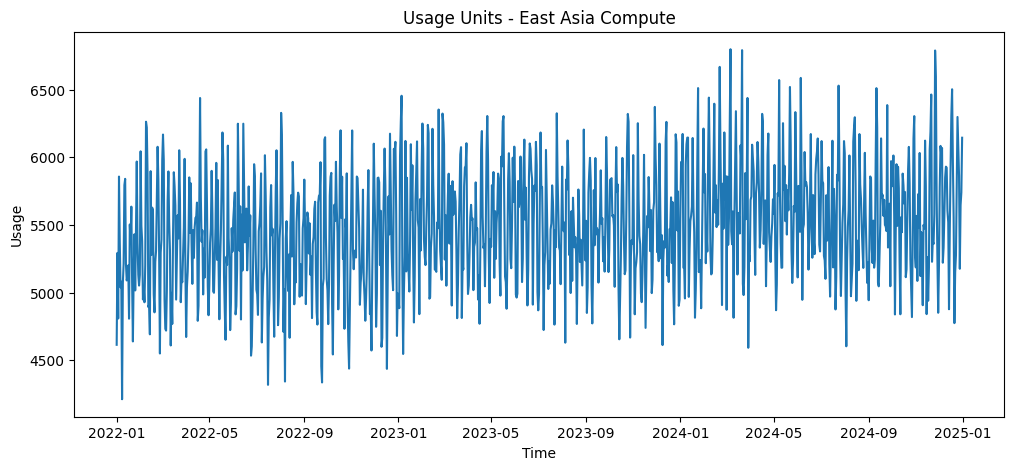

In [35]:
plt.figure(figsize=(12,5))
plt.plot(sample["timestamp"], series)
plt.title("Usage Units - East Asia Compute")
plt.xlabel("Time")
plt.ylabel("Usage")
plt.show()

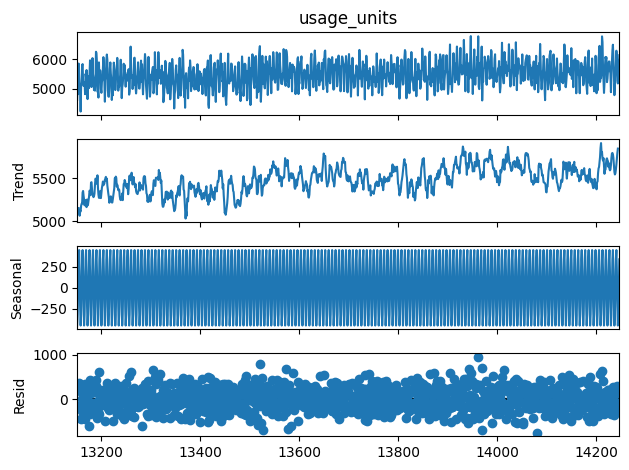

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(series, model='additive', period=7)

decomposition.plot()
plt.show()

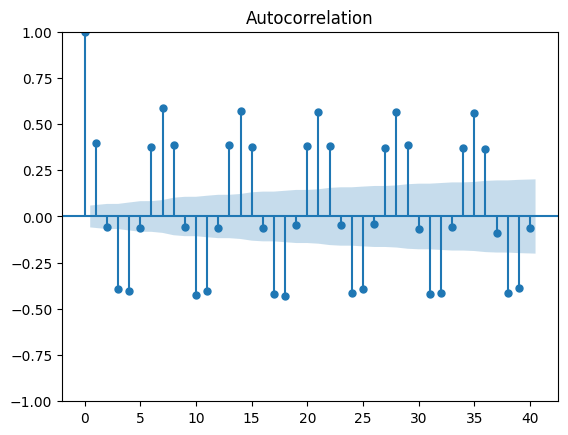

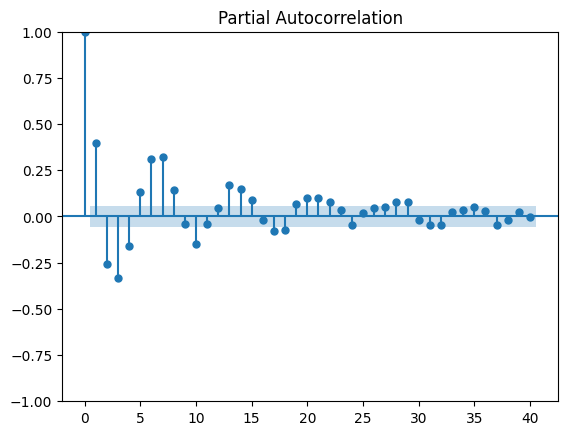

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(series.dropna(), lags=40)
plt.show()

plot_pacf(series.dropna(), lags=40)
plt.show()

##Statistical Tests

In [38]:
from statsmodels.tsa.stattools import adfuller

results = []

for (region, service), group in df.groupby(["region","service_type"]):

    series = group.sort_values("timestamp")["usage_units"].dropna()

    adf_stat, p_value, _, _, _, _ = adfuller(series)

    results.append({
        "region": region,
        "service_type": service,
        "adf_stat": adf_stat,
        "p_value": p_value,
        "stationary": p_value < 0.05
    })

adf_results = pd.DataFrame(results)
adf_results

,region,service_type,adf_stat,p_value,stationary
0,Australia East,Compute,-2.263997,0.183843,False
1,Australia East,Storage,-2.311681,0.168228,False
2,Australia Southeast,Compute,-0.941597,0.773966,False
3,Australia Southeast,Storage,-0.973297,0.762879,False
4,Brazil South,Compute,-2.541301,0.105746,False
...,...,...,...,...,...
59,West US,Storage,-2.450329,0.128032,False
60,West US 2,Compute,-2.837674,0.053090,False
61,West US 2,Storage,-2.548030,0.104221,False
62,West US 3,Compute,-2.028040,0.274416,False


In [39]:
adf_results['stationary'].value_counts()

,count
stationary,
False,58
True,6


In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

seasonal_strength = []

for (region, service), group in df.groupby(["region","service_type"]):

    series = group.sort_values("timestamp")["usage_units"].dropna()

    decomposition = seasonal_decompose(series, model='additive', period=7)

    seasonal_var = np.var(decomposition.seasonal)
    total_var = np.var(series)

    strength = seasonal_var / total_var

    seasonal_strength.append({
        "region": region,
        "service_type": service,
        "seasonal_strength": strength
    })

season_df = pd.DataFrame(seasonal_strength)

In [41]:
season_df["seasonal_strength"].describe()

,seasonal_strength
count,64.000000
mean,0.434961
std,0.064409
min,0.323253
25%,0.375847
50%,0.441013
75%,0.490723
max,0.570648


In [42]:
auto_results = []

for (region, service), group in df.groupby(["region","service_type"]):

    series = group.sort_values("timestamp")["usage_units"].dropna()

    auto_results.append({
        "region": region,
        "service_type": service,
        "lag1": series.autocorr(lag=1),
        "lag7": series.autocorr(lag=7),
        "lag30": series.autocorr(lag=30)
    })

auto_all = pd.DataFrame(auto_results)

auto_all.describe()

,lag1,lag7,lag30
count,64.000000,64.000000,64.000000
mean,0.490843,0.654861,0.115338
std,0.076159,0.053821,0.124020
min,0.372134,0.557004,-0.071278
25%,0.426638,0.614976,0.010036
50%,0.482271,0.653689,0.086841
75%,0.564142,0.702262,0.217607
max,0.627086,0.759484,0.332274


In [43]:
macro_corr = df.groupby(["region","service_type"])[
    ["usage_units","gdp_growth_rate","it_spending_index","enterprise_demand_index","internet_traffic_growth"]
].corr().reset_index()

macro_corr.head()

,region,service_type,level_2,usage_units,gdp_growth_rate,it_spending_index,enterprise_demand_index,internet_traffic_growth
0,Australia East,Compute,usage_units,1.000000,0.007843,0.291425,0.291401,-0.049119
1,Australia East,Compute,gdp_growth_rate,0.007843,1.000000,-0.259446,-0.259382,0.017484
2,Australia East,Compute,it_spending_index,0.291425,-0.259446,1.000000,0.999953,-0.125445
3,Australia East,Compute,enterprise_demand_index,0.291401,-0.259382,0.999953,1.000000,-0.125416
4,Australia East,Compute,internet_traffic_growth,-0.049119,0.017484,-0.125445,-0.125416,1.000000


In [44]:
df[["usage_units","gdp_growth_rate","it_spending_index","enterprise_demand_index","internet_traffic_growth"]].corr()

,usage_units,gdp_growth_rate,it_spending_index,enterprise_demand_index,internet_traffic_growth
usage_units,1.000000,-0.018909,0.190058,0.193722,-0.026104
gdp_growth_rate,-0.018909,1.000000,-0.259446,-0.210465,0.017484
it_spending_index,0.190058,-0.259446,1.000000,0.811235,-0.125445
enterprise_demand_index,0.193722,-0.210465,0.811235,1.000000,-0.101766
internet_traffic_growth,-0.026104,0.017484,-0.125445,-0.101766,1.000000


In [45]:
df

,timestamp,region,service_type,usage_units,provisioned_capacity,utilization_pct,headroom_units,unit_price,cost_usd,wasted_capacity_cost,...,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,z_score,usage_spike,capacity_risk_flag,underutilized_flag,utilization_gap,macro_pressure
0,2022-01-01,Australia East,Compute,4185.61,8660.71,0.483287,4475.10,0.5,2092.81,2237.550,...,NaN,NaN,NaN,NaN,NaN,0,0,1,-0.138612,3.020000
1,2022-01-02,Australia East,Compute,3992.20,8660.71,0.460955,4668.51,0.5,1996.10,2334.255,...,NaN,NaN,NaN,NaN,NaN,0,0,1,-0.160944,3.030606
2,2022-01-03,Australia East,Compute,4350.32,8660.71,0.502305,4310.39,0.5,2175.16,2155.195,...,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.119594,3.051525
3,2022-01-04,Australia East,Compute,4614.75,8660.71,0.532837,4045.96,0.5,2307.37,2022.980,...,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.089062,3.072149
4,2022-01-05,Australia East,Compute,4830.22,8660.71,0.557716,3830.49,0.5,2415.11,1915.245,...,NaN,NaN,NaN,NaN,NaN,0,0,0,-0.064183,3.092781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70139,2024-12-27,West US 3,Storage,3796.51,6730.00,0.564117,2933.49,0.2,759.30,586.698,...,3907.982857,321.679482,3939.724000,301.083536,-0.346534,0,0,0,-0.057782,3.684845
70140,2024-12-28,West US 3,Storage,3544.53,6730.00,0.526676,3185.47,0.2,708.91,637.094,...,3930.098571,283.120702,3925.777667,309.543201,-1.361852,0,0,0,-0.095223,3.710421
70141,2024-12-29,West US 3,Storage,3903.46,6730.00,0.580009,2826.54,0.2,780.69,565.308,...,3957.628571,267.156166,3937.119333,301.940653,-0.202760,0,0,0,-0.041890,3.723510
70142,2024-12-30,West US 3,Storage,4125.10,6730.00,0.612942,2604.90,0.2,825.02,520.980,...,4003.477143,263.948840,3954.693333,296.814386,0.460782,0,0,0,-0.008957,3.749400
